# Bavian Resultater og Fortolkning

Formålet med denne notebook er at samle og fortolke de resultater jeg har fået fra notebook 03–06 og lave yderligere analyser direkte på bavian-data.
Så jeg kommer ind på følgende i denne notebook:

1. Overblik over alle populationer (SFS + heterozygositet)
2. Model-fit: forventet vs. observeret SFS per population
3. Two-island model — Eastern yellow vs. Kinda
4. IM-model — Southern olive vs. Eastern yellow  
5. Sammenligning af split-tider med Sørensen et al. (2023)
6. Tajima's D — test for neutral evolution
7. Theta-estimater på tværs af populationer

## Indlæs alle gemte data 

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level,
)
set_log_level("WARNING")

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme
from pathlib import Path


all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


In [2]:
# Indlæs alle gemte data 
pi_df = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)
df_ye = pd.read_csv(OUT_DIR / "derived_counts_yellow_east.csv")
df_ki = pd.read_csv(OUT_DIR / "derived_counts_kinda.csv")
df_os = pd.read_csv(OUT_DIR / "derived_counts_olive_south.csv")
df_yw = pd.read_csv(OUT_DIR / "derived_counts_yellow_west.csv")
df_og = pd.read_csv(OUT_DIR / "derived_counts_olive_gog.csv")

sfs_ye = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv",  index_col=0).squeeze()
sfs_ki = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",         index_col=0).squeeze()
sfs_os = pd.read_csv(OUT_DIR / "sfs_folded_olive_south.csv",  index_col=0).squeeze()
sfs_yw = pd.read_csv(OUT_DIR / "sfs_folded_yellow_west.csv",  index_col=0).squeeze()
sfs_og = pd.read_csv(OUT_DIR / "sfs_folded_olive_gog.csv",    index_col=0).squeeze()

pop_names = {
    "Eastern yellow (Mikumi)": (df_ye, sfs_ye, "C1"),
    "Kinda":                   (df_ki, sfs_ki, "C2"),
    "Southern olive":          (df_os, sfs_os, "C3"),
    "Western yellow (Mahale)": (df_yw, sfs_yw, "C4"),
    "Olive gog":               (df_og, sfs_og, "C5"),
}
print("Data indlæst OK")
print(pi_df.round(6))

Data indlæst OK
                               pi
Eastern yellow (Mikumi)  0.002584
Kinda                    0.002861
Southern olive           0.001969
Western yellow (Mahale)  0.002868
Olive gog                0.001742


## Standard coalescent til modelmatch

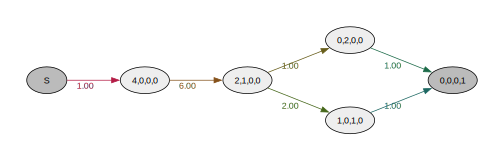

In [3]:
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

graph = Graph(coalescent_1param)
reward_matrix = graph.states().T
graph.plot()

## Theta estimater per popultation via MoM

In [4]:
# For hver population: subsample til n=4, beregn empirisk SFS,
# fit standard-coalescent via MoM og estimer theta = 1/Ne

def load_ktons(path, n_use=4, seed=0):
    df = pd.read_csv(path)
    df = df[df["nr_samples"] >= n_use].copy()
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=n_use,
    )
    return k[(k > 0) & (k < n_use)]

paths = {
    "Eastern yellow (Mikumi)": OUT_DIR / "derived_counts_yellow_east.csv",
    "Kinda":                   OUT_DIR / "derived_counts_kinda.csv",
    "Southern olive":          OUT_DIR / "derived_counts_olive_south.csv",
    "Western yellow (Mahale)": OUT_DIR / "derived_counts_yellow_west.csv",
    "Olive gog":               OUT_DIR / "derived_counts_olive_gog.csv",
}

theta_results = {}
for name, path in paths.items():
    k = load_ktons(path)
    # Brug reward-baseret MoM: matcher forventet branch-længde per bin
    rewards = reward_matrix[:-1]  # udelad 4-ton (absorberende)
    n_obs = len(k)
    n_feat = len(rewards)
    data_2d = np.full((n_obs * n_feat, n_feat), np.nan)
    for i, r in enumerate(rewards):
        obs_i = graph.sample(n_obs, rewards=r)
        data_2d[i*n_obs:(i+1)*n_obs, i] = obs_i

    from phasic import dense_to_sparse
    sparse = dense_to_sparse(data_2d)
    try:
        mom = graph.method_of_moments(sparse, rewards=rewards)
        theta_results[name] = {
            "theta": mom.theta[0],
            "std": mom.std[0],
            "Ne": (1/mom.theta[0]) * (pi_df.loc[name, "pi"] / (4 * MUT_RATE))
                  if name in pi_df.index else None,
        }
    except Exception as e:
        print(f"{name}: MoM fejlede — {e}")

theta_df = pd.DataFrame(theta_results).T
print("\nTheta-estimater per population:")
print(theta_df.round(4))

W0426 17:17:35.619889 3346333 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0426 17:17:37.540208 3346333 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.



Theta-estimater per population:
                          theta     std          Ne
Eastern yellow (Mikumi)  1.0015  0.0009  71681.0002
Kinda                    0.9995  0.0009  79498.3886
Southern olive           1.0004  0.0011  54680.2085
Western yellow (Mahale)  1.0007  0.0009  79610.4502
Olive gog                1.0007  0.0011  48357.3703


## Forventet vs. observeret SFS per population 

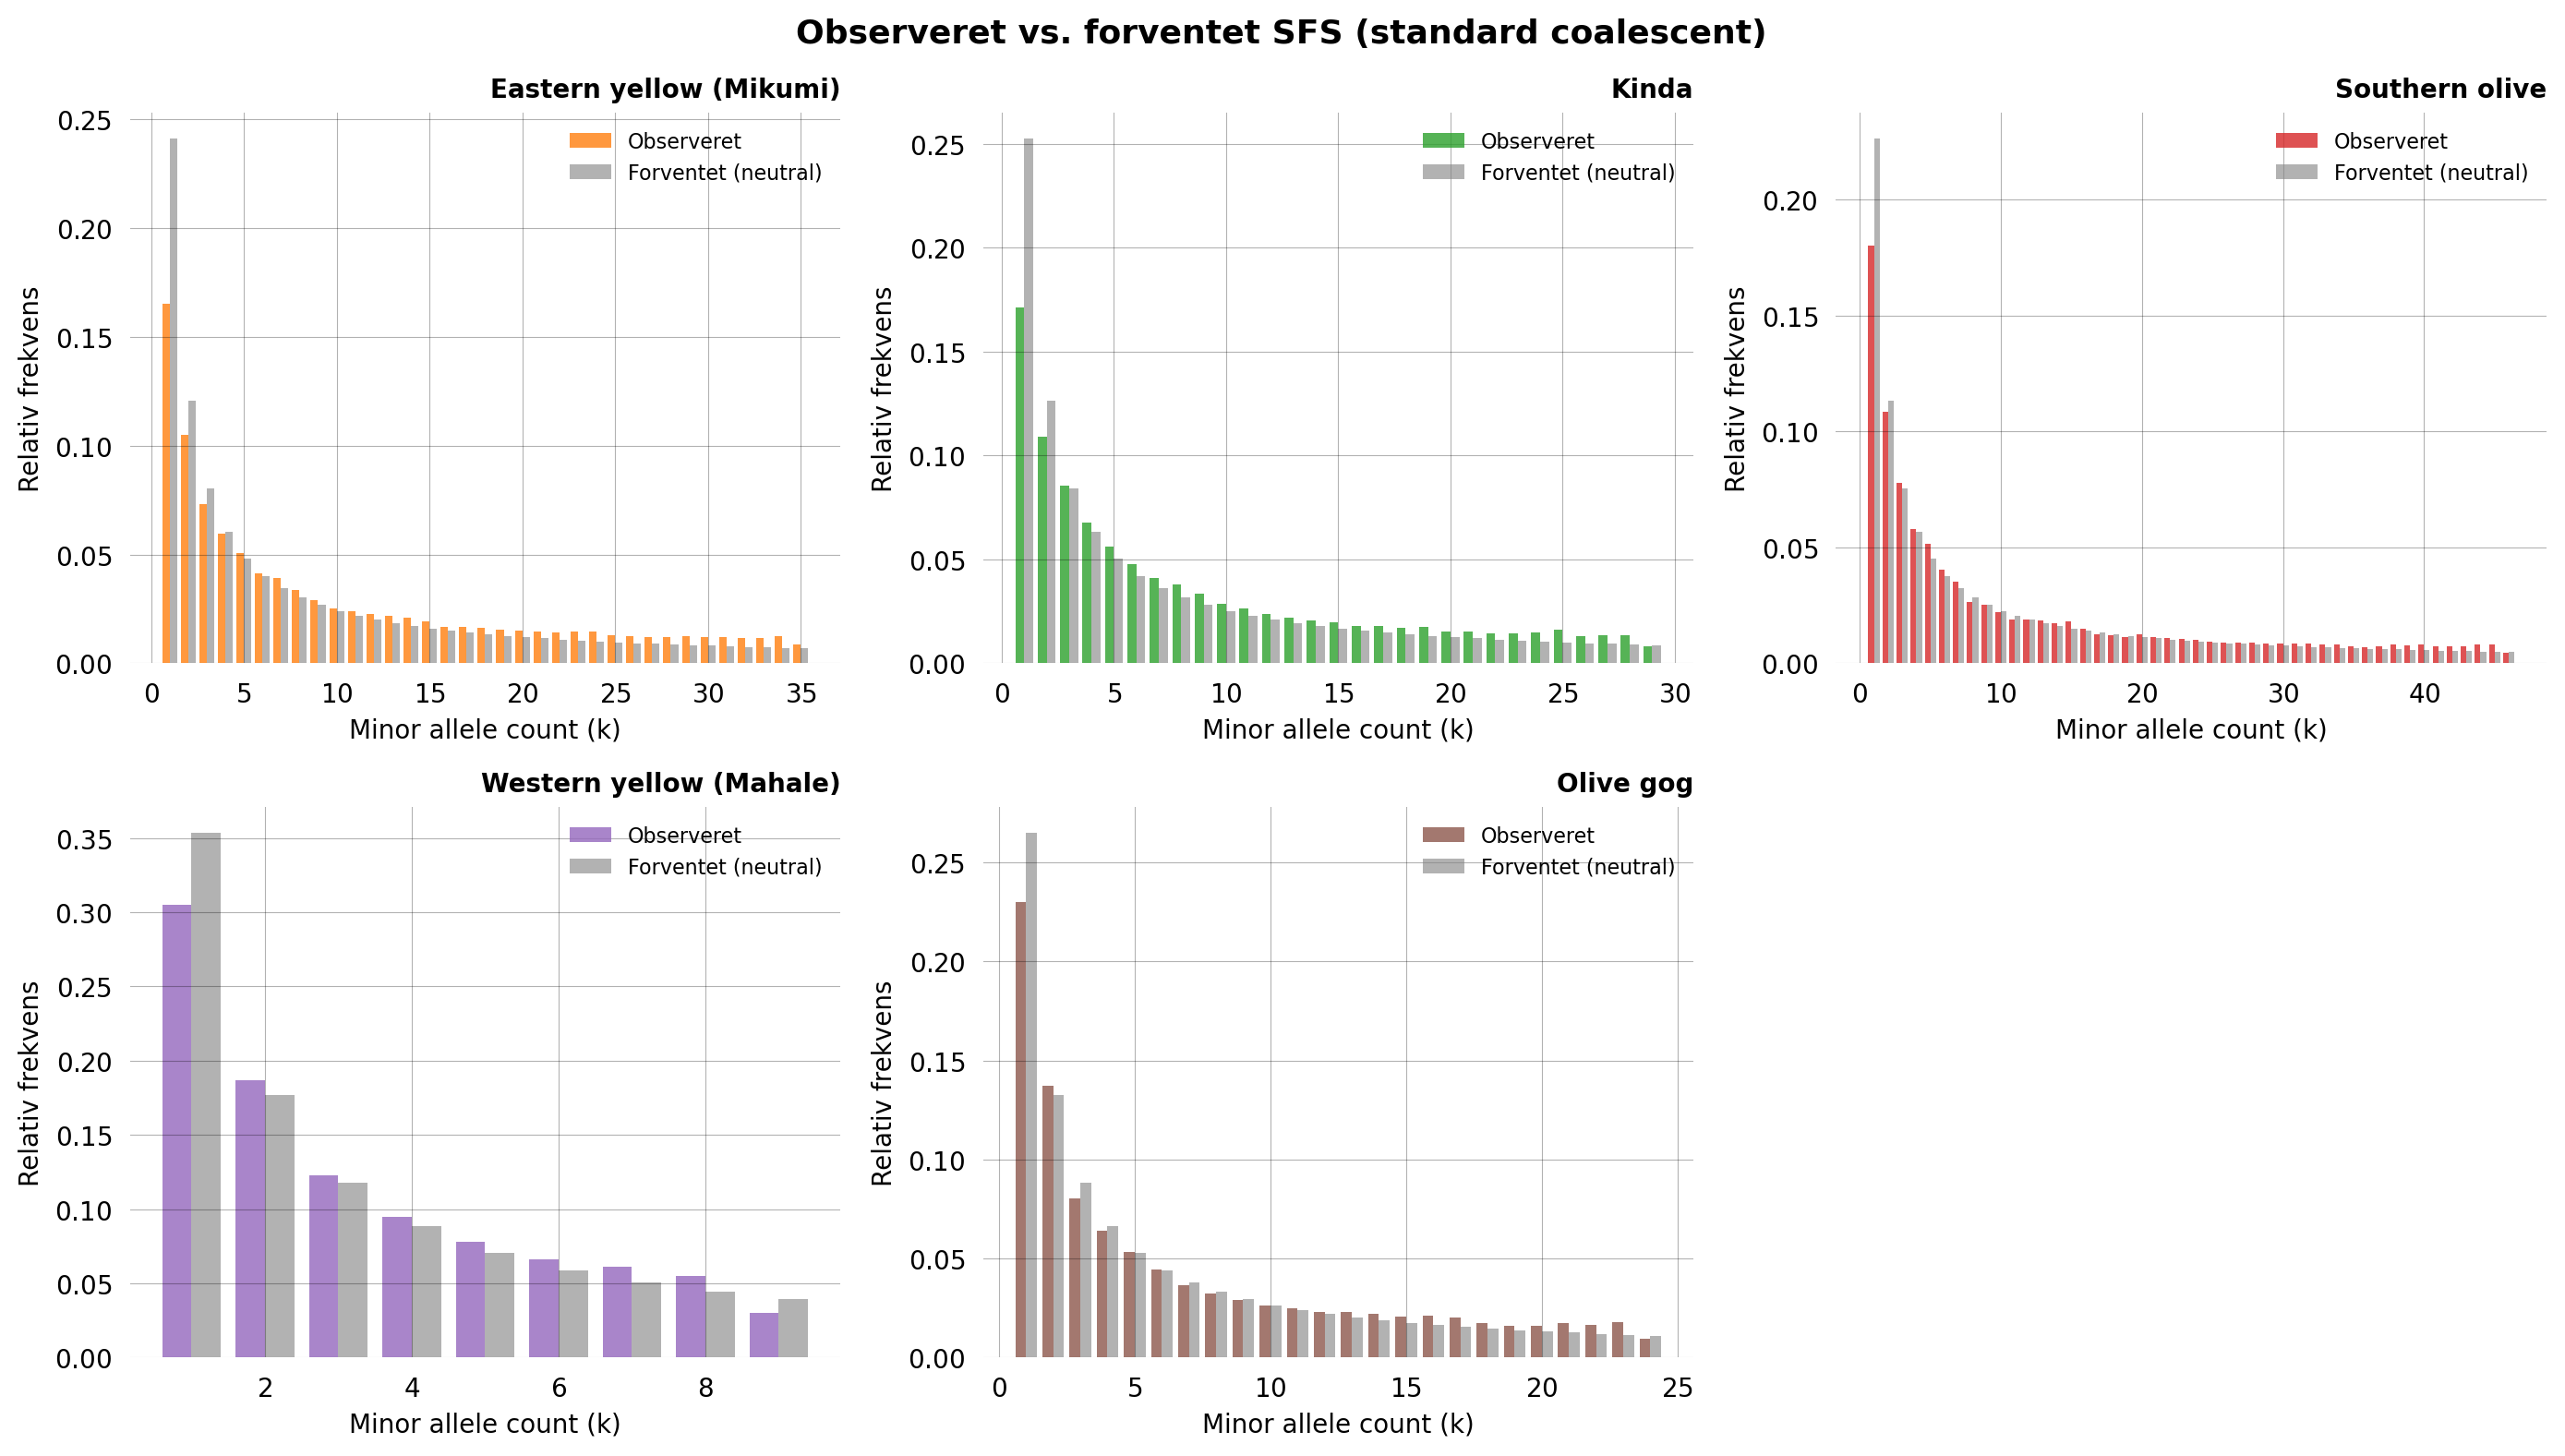

In [5]:
# For hver population: fitter theta med MoM og sammenlign forventet SFS med observeret

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

pop_items = list(pop_names.items())
for ax_idx, (name, (df_pop, sfs_obs, color)) in enumerate(pop_items):
    ax = axes[ax_idx]
    pi_val = pi_df.loc[name, "pi"]
    Ne_ref = pi_val / (4 * MUT_RATE)

    theta_pi = pi_val  # pi ≈ theta for panmiktisk population

    x = np.arange(1, len(sfs_obs) + 1)
    # Normaliser begge til frekvenser
    obs_norm = sfs_obs.values / sfs_obs.values.sum()
    exp_sfs = np.array([1/k for k in x])
    exp_norm = exp_sfs / exp_sfs.sum()

    ax.bar(x - 0.2, obs_norm, width=0.4, label="Observeret", color=color, alpha=0.8)
    ax.bar(x + 0.2, exp_norm, width=0.4, label="Forventet (neutral)", color="grey", alpha=0.6)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Minor allele count (k)")
    ax.set_ylabel("Relativ frekvens")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Fjern tom subplot
axes[-1].set_visible(False)
plt.suptitle("Observeret vs. forventet SFS (standard coalescent)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Tajima's D per population

In [6]:
# Tajima's D sammenligner pi (pairwise diversity) med Watterson's theta
# D > 0: overskud af common variants → balancerende selektion eller admixture
# D < 0: overskud af singletons → nylig ekspansion eller purifying selektion

def tajimas_d(df_pop, n=4):
    """
    Beregner Tajima's D for en population.
    Kræver derived count data og subsampler til n haplotyper.
    """
    rng = np.random.default_rng(0)
    k = rng.hypergeometric(
        ngood=df_pop["derived_count"].values,
        nbad=(df_pop["nr_samples"] - df_pop["derived_count"]).values,
        nsample=n,
    )
    k = k[(k > 0) & (k < n)]
    S = len(k)  # antal segregerende sites

    if S == 0:
        return np.nan, np.nan, np.nan

    # Watterson's theta_W = S / a1
    a1 = sum(1/i for i in range(1, n))
    theta_W = S / a1

    # Pi (gennemsnitlig pairwise differences)
    pi_val = sum(ki * (n - ki) for ki in k) * 2 / (n * (n-1))

    # Tajima's D (forenklet uden variansterm)
    # Fuld formel kræver b1, b2, c1, c2 korrektionstermerne
    b1 = (n + 1) / (3 * (n - 1))
    b2 = (2 * (n**2 + n + 3)) / (9 * n * (n - 1))
    c1 = b1 - 1/a1
    a2 = sum(1/i**2 for i in range(1, n))
    c2 = b2 - (n + 2)/(a1 * n) + a2/a1**2
    e1 = c1 / a1
    e2 = c2 / (a1**2 + a2)
    var_d = e1 * S + e2 * S * (S - 1)
    D = (pi_val - theta_W) / np.sqrt(var_d) if var_d > 0 else np.nan

    return D, pi_val, theta_W

tajima_results = {}
for name, (df_pop, _, _) in pop_names.items():
    D, pi_v, theta_w = tajimas_d(df_pop)
    tajima_results[name] = {"Tajima's D": round(D, 4), "pi": round(pi_v, 6), "theta_W": round(theta_w, 6)}

tajima_df = pd.DataFrame(tajima_results).T
print("Tajima's D per population:")
print(tajima_df)
print()
print("Fortolkning:")
print("  D ≈ 0:  konsistent med neutral evolution og konstant population")
print("  D > 0:  overskud af common variants (admixture, balancerende selektion, bottleneck)")
print("  D < 0:  overskud af singletons (nylig ekspansion, purifying selektion)")

Tajima's D per population:
                         Tajima's D             pi        theta_W
Eastern yellow (Mikumi)      0.0009  189245.500000  189230.181818
Kinda                       -0.0206  209844.833333  210255.818182
Southern olive              -0.0335  143659.000000  144118.363636
Western yellow (Mahale)     -0.0327  219016.833333  219700.909091
Olive gog                   -0.0235  128356.166667  128643.818182

Fortolkning:
  D ≈ 0:  konsistent med neutral evolution og konstant population
  D > 0:  overskud af common variants (admixture, balancerende selektion, bottleneck)
  D < 0:  overskud af singletons (nylig ekspansion, purifying selektion)


### Visualisering af Tajima's D

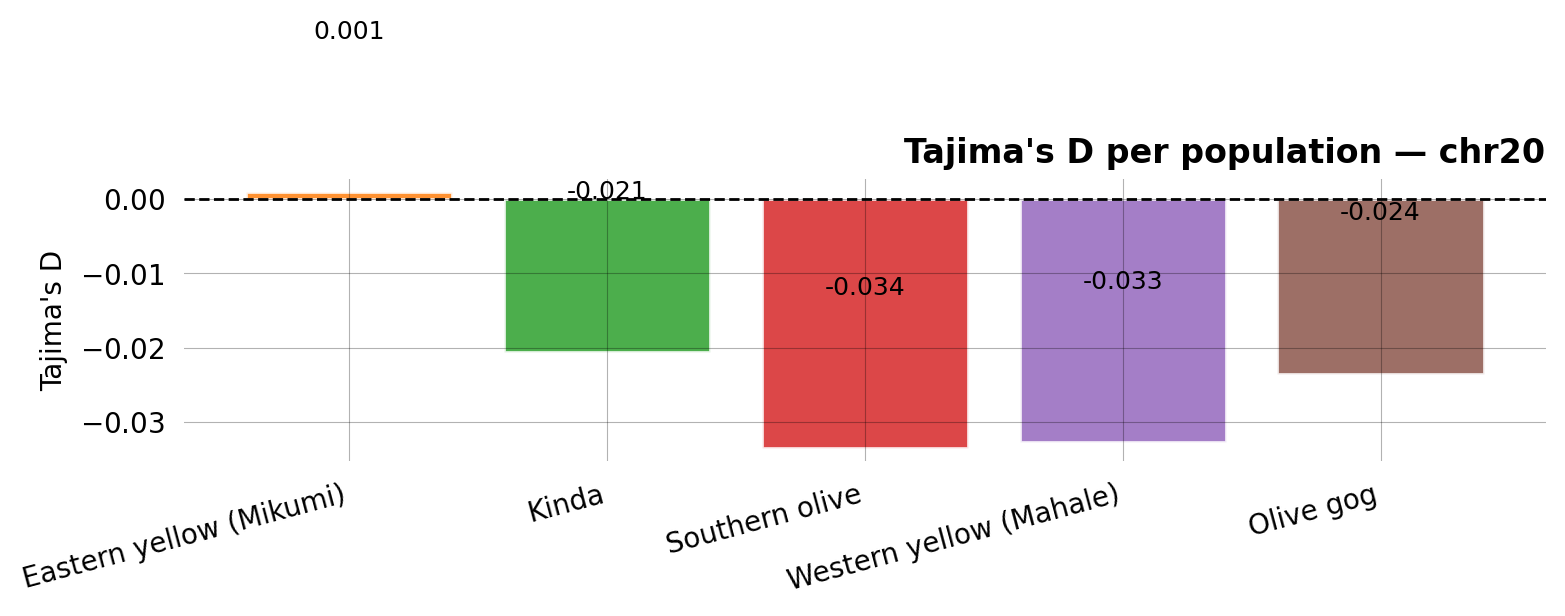

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["C1", "C2", "C3", "C4", "C5"]
bars = ax.bar(tajima_df.index, tajima_df["Tajima's D"], color=colors, alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_ylabel("Tajima's D")
ax.set_title("Tajima's D per population — chr20", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, tajima_df["Tajima's D"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Sammenligning af alle estimater i en tabel

In [9]:
summary = pd.DataFrame({
    "pi": pi_df["pi"],
    "Ne_ref": (pi_df["pi"] / (4 * MUT_RATE)).astype(int),
    "Tajima's D": tajima_df["Tajima's D"],
})
print("Samlet overblik per population:")
print(summary.round(6))

Samlet overblik per population:
                               pi  Ne_ref  Tajima's D
Eastern yellow (Mikumi)  0.002584   71788      0.0009
Kinda                    0.002861   79458     -0.0206
Southern olive           0.001969   54704     -0.0335
Western yellow (Mahale)  0.002868   79663     -0.0327
Olive gog                0.001742   48388     -0.0235


## Two-island model på Eastern Yellow vs. Kinda

In [11]:
# Genbygger modellen og kører inferens (resultaterne fra NB 04 genbruges her)

indexer_2i = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ]
)
ipv_2i = [0] * indexer_2i.state_length
ipv_2i[indexer_2i.lineages.props_to_index(descendants=1, in_pop=1)] = nr_samples

@with_ipv(ipv_2i)
def two_island(state, indexer=None):
    transitions = []
    if state.sum() <= 1:
        return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if pi.in_pop != pj.in_pop: continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1 
        new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer.lineages.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = [rate if pi.in_pop == 1 else 0, 
                 rate if pi.in_pop == 2 else 0, 
                 0]
        transitions.append([new, coeff])

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.lineages.index_to_props(i)
        other = 2 if pi.in_pop == 1 else 1
        new = state.copy()
        new[i] -= 1
        k = indexer.lineages.props_to_index(descendants=pi.descendants, in_pop=other)
        new[k] += 1
        coeff = [0, 0, state[i]]
        transitions.append([new, coeff])

    return transitions

graph_2i = Graph(two_island, indexer=indexer_2i)

mutation_rate = 1.0
joint_graph_2i = graph_2i.joint_prob_graph(
    indexer_2i,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate,
)

tbl_2i = joint_graph_2i.joint_prob_table()
defect_2i = 1 - tbl_2i['prob'].sum()
print(f"Two-island joint probability: {len(tbl_2i)} mønstre, defekt={defect_2i.item():.4f}")

Two-island joint probability: 7 mønstre, defekt=0.8584


## Indlæs eastern yellow og kør SVGD

In [12]:
k_east = load_ktons(OUT_DIR / "derived_counts_yellow_east.csv", n_use=nr_samples)
feature_cols = [c for c in tbl_2i.columns if c.startswith("descendants")]
allowed = set(tuple(int(x) for x in r) for r in tbl_2i[feature_cols].values)
obs_east = []
for k in k_east:
    o = [0] * len(feature_cols)
    if 0 < k - 1 < len(o):
        o[k - 1] = 1
    if tuple(o) in allowed:
        obs_east.append(o)

print(f"Eastern yellow: {len(obs_east):,} brugbare observationer")

rng = np.random.default_rng(0)
use = [obs_east[i] for i in rng.choice(len(obs_east), min(5000, len(obs_east)), replace=False)]

svgd_2i = joint_graph_2i.svgd(
    observed_data=use,
    fixed=[(3, mutation_rate)],
    n_iterations=150,
    n_particles=80,
    prior=[GaussPrior(ci=[0.1, 5.0]), GaussPrior(ci=[0.1, 5.0]),
           GaussPrior(ci=[0.0, 3.0]), None],
    learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
)

print("\nTwo-island model — Eastern yellow (Mikumi):")
svgd_2i.summary(ci_method="hpd", ci_level=0.95)


Two-island model — Eastern yellow (Mikumi):


Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.9082     5.1755     1.3561     3.2504       6.9082      
1          No         3.1561     2.8471     1.1652     0.6910       4.7325      
2          No         3.0628     2.0025     0.8691     0.2932       3.1262      
3          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 150


### Fortolkning - Two-island model


Two-island biologisk fortolkning:
  N_ref (fra pi):          71,789
  N1 (Eastern yellow):     13,871 individer
  N2 (Kinda):              25,215 individer
  Migration (m):           1.39e-05 per lineage per generation

  Sørensen et al. (2023): gene flow dokumenteret


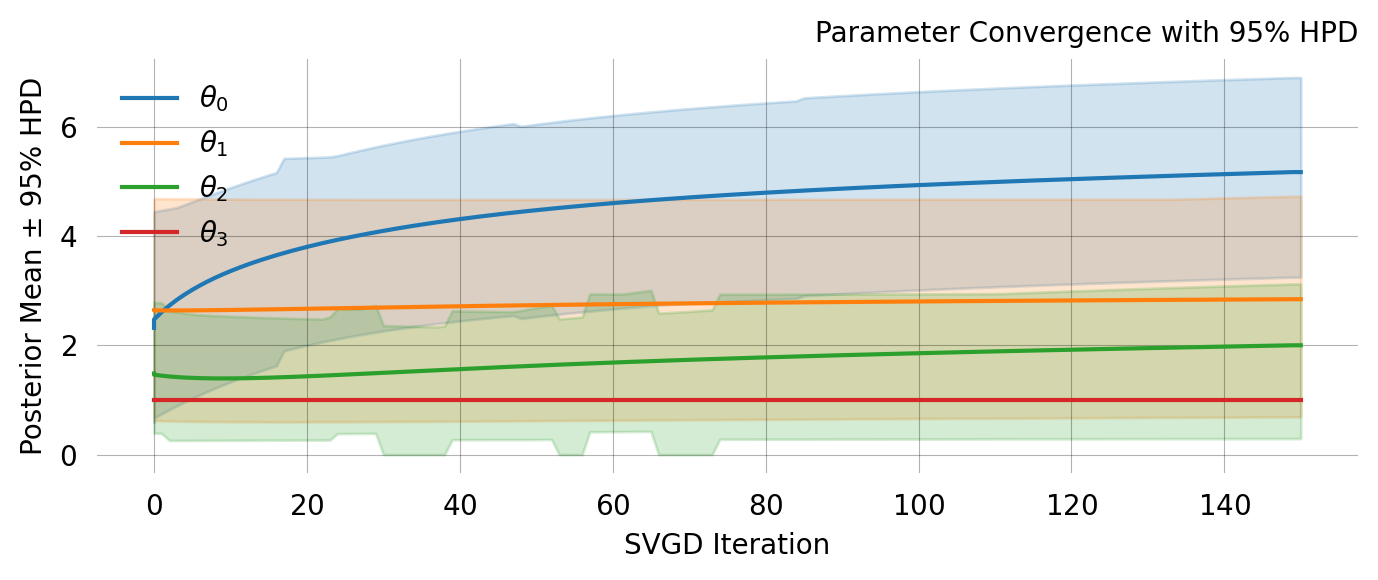

<Figure size 500x370 with 0 Axes>

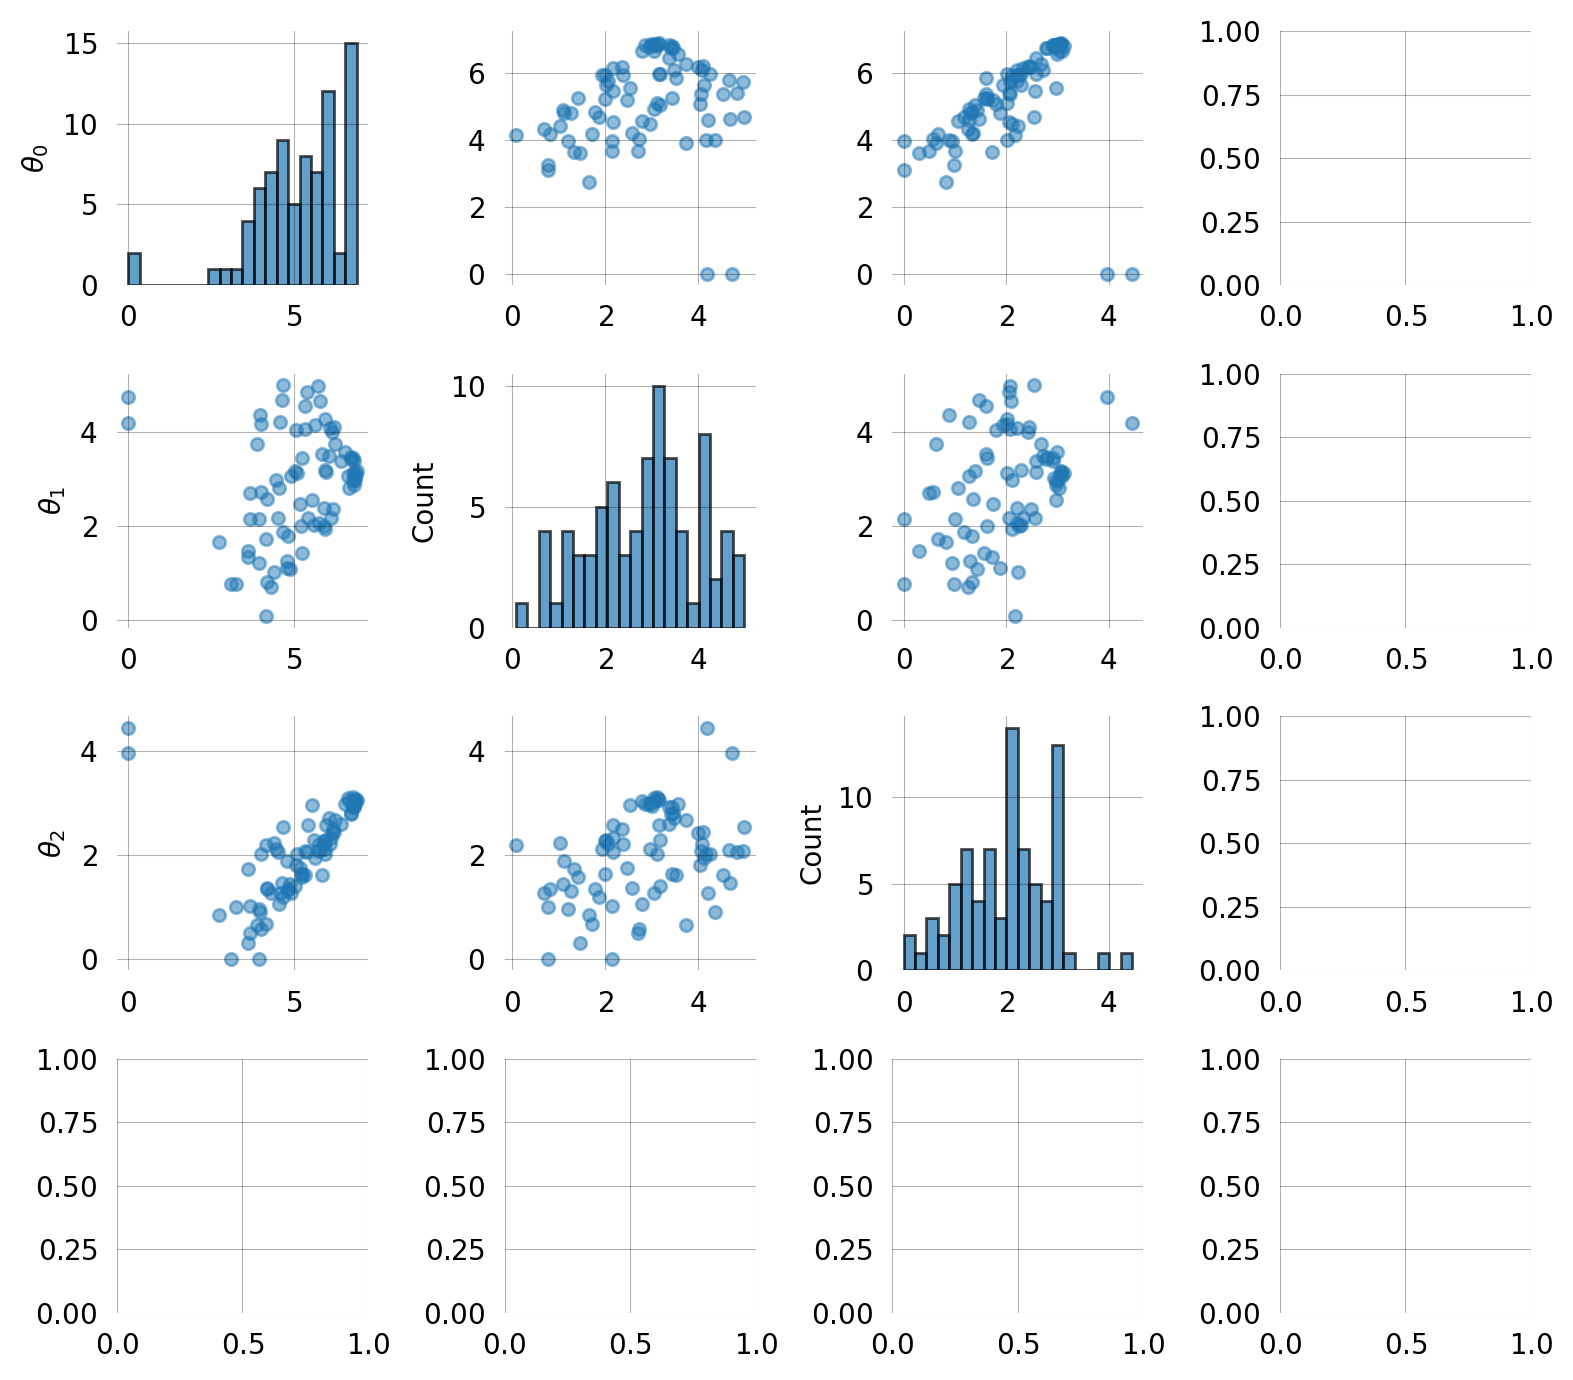

<Figure size 500x370 with 0 Axes>

In [13]:
pi_east = pi_df.loc["Eastern yellow (Mikumi)", "pi"]
Ne_ref_east = pi_east / (4 * MUT_RATE)
res_2i = svgd_2i.get_results()
theta_2i = res_2i["theta_mean"]

N1_est = (1 / theta_2i[0]) * Ne_ref_east
N2_est = (1 / theta_2i[1]) * Ne_ref_east
m_est  = theta_2i[2] / (2 * Ne_ref_east)

print(f"\nTwo-island biologisk fortolkning:")
print(f"  N_ref (fra pi):          {Ne_ref_east:,.0f}")
print(f"  N1 (Eastern yellow):     {N1_est:,.0f} individer")
print(f"  N2 (Kinda):              {N2_est:,.0f} individer")
print(f"  Migration (m):           {m_est:.2e} per lineage per generation")
print(f"\n  Sørensen et al. (2023): gene flow dokumenteret")

svgd_2i.plot_ci(ci_method="hpd")
plt.suptitle("Posterior CI — Eastern yellow (Two-island model)")
plt.show()

svgd_2i.plot_pairwise()
plt.suptitle("Posterior pairwise — Two-island model", y=1.02)
plt.show()

## IM-model på Southern olive vs. Eastern Yellow

In [15]:
# Genbrug epoch-konstruktionen fra NB 05

N_PARAMS = 5
t_split = 1.0
epochs_im = [0.0, t_split]

indexer_im = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ],
    slots=["epoch"],
)

ipv_im = [0] * indexer_im.state_length
ipv_im[indexer_im.props_to_index(descendants=1, in_pop=1)] = nr_samples

def add_epoch_im(graph, callback, epochs, epoch_idx, indexer):
    epoch = epochs[epoch_idx]
    stop_probs    = np.array(graph.stop_probability(epoch))
    accum_v_time  = np.array(graph.accumulated_occupancy(epoch))
    with np.errstate(invalid="ignore"):
        epoch_trans_rates = stop_probs / accum_v_time

    for i in range(1, graph.vertices_length() - 1):
        if np.isnan(epoch_trans_rates[i]): continue
        if graph.vertex_at(i).edges_length() == 0: continue
        vertex = graph.vertex_at(i)
        state  = vertex.state()
        if state[indexer.epoch] != epoch_idx - 1: continue
        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child = graph.find_or_create_vertex(sister_state)
        coeff = np.zeros(graph.param_length())
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)

    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)

def im_callback(state, epochs=None, epoch_idx=None, indexer=None):
    transitions = []
    epoch_idx = int(epoch_idx)
    if state[indexer.epoch] != epoch_idx: return transitions
    lineage_sum = sum(state[k] for k in range(indexer.state_length) if k != indexer.epoch)
    if lineage_sum <= 1: return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if epoch_idx == 0 and pi.in_pop != pj.in_pop: continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer_im.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = np.zeros(N_PARAMS)
        coeff[0 if (epoch_idx == 0 and pi.in_pop == 1) else
              1 if (epoch_idx == 0 and pi.in_pop == 2) else 3] = rate
        transitions.append([new, coeff])

    if epoch_idx == 0:
        for i in range(indexer.state_length):
            if i == indexer_im.epoch or state[i] == 0: continue
            pi = indexer.lineages.index_to_props(i)
            other = 2 if pi.in_pop == 1 else 1
            new = state.copy(); new[i] -= 1
            k = indexer_im.props_to_index(descendants=pi.descendants, in_pop=other)
            new[k] += 1
            coeff = np.zeros(N_PARAMS); coeff[2] = state[i]
            transitions.append([new, coeff])

    return transitions

theta_init = [1.0, 0.5, 0.8, 0.7, 1.0]
graph_im = Graph(im_callback, ipv=ipv_im, epochs=epochs_im, epoch_idx=0, indexer=indexer_im)
graph_im.update_weights(theta_init)
add_epoch_im(graph_im, im_callback, epochs_im, 1, indexer_im)
graph_im.update_weights(theta_init)

print(f"IM-model: {graph_im.vertices_length()} state, {graph_im.param_length()} parametre")

IM-model: 41 state, 5 parametre


### IM joint probability graf

In [16]:
mutation_rate_im = 1.0
joint_graph_im = graph_im.joint_prob_graph(
    indexer_im,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate_im,
)
theta_joint_im = theta_init + [mutation_rate_im]
joint_graph_im.update_weights(theta_joint_im)

tbl_im = joint_graph_im.joint_prob_table()
defect_im = 1 - tbl_im['prob'].sum()
print(f"IM-model joint probability: {len(tbl_im)} mønstre, defekt={defect_im.item():.4f}")

MUT_IDX_IM    = joint_graph_im.param_length() - 1
EPOCH_IDX_IM  = MUT_IDX_IM - 1
fixed_im = [(EPOCH_IDX_IM, 1.0), (MUT_IDX_IM, mutation_rate_im)]
prior_im = ([GaussPrior(ci=[0.1, 5.0])] * 4 + [None, None])[:joint_graph_im.param_length()]

IM-model joint probability: 14 mønstre, defekt=0.8243


In [17]:
# Kør SVGD på southern olive
k_oliv = load_ktons(OUT_DIR / "derived_counts_olive_south.csv", n_use=nr_samples)
feature_cols_im = [c for c in tbl_im.columns if c.startswith("descendants")]
allowed_im = set(tuple(int(x) for x in r) for r in tbl_im[feature_cols_im].values)
obs_oliv = []
for k in k_oliv:
    o = [0] * len(feature_cols_im)
    if 0 < k - 1 < len(o): o[k-1] = 1
    if tuple(o) in allowed_im: obs_oliv.append(o)

rng2 = np.random.default_rng(1)
use_oliv = [obs_oliv[i] for i in rng2.choice(len(obs_oliv), min(5000, len(obs_oliv)), replace=False)]
print(f"Southern olive: {len(use_oliv):,} observationer til SVGD")

svgd_im = joint_graph_im.svgd(
    observed_data=use_oliv,
    fixed=fixed_im,
    n_iterations=150,
    n_particles=80,
    prior=prior_im,
    learning_rate=ExpStepSize(first_step=0.06, last_step=0.01, tau=40.0),
)
print("\nIM-model — Southern olive:")
svgd_im.summary(ci_method="hpd", ci_level=0.95)


IM-model — Southern olive:


Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         5.5806     4.3596     1.3653     0.0000       5.6051      
1          No         1.5300     2.5059     1.2604     0.0000       4.8171      
2          No         2.9790     3.0159     1.0812     1.1963       5.7247      
3          No         3.6601     3.0154     1.0408     0.8243       4.6401      
4          Yes        1.0000     NA         NA         NA           NA          
5          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 150


### Fortolkning IM-modellen 


IM-model biologisk fortolkning:
  N_ref (fra pi):           54,704
  N1 (Southern olive):      12,548 individer
  N2 (Eastern yellow):      21,831 individer
  N_ancestral:              18,141 individer
  Migration (m):            2.76e-05 per lineage per generation
  Split-tid:                1,203,497 år

  Sammenlign: Sørensen et al. (2023) estimerer split ~1 mio. år siden


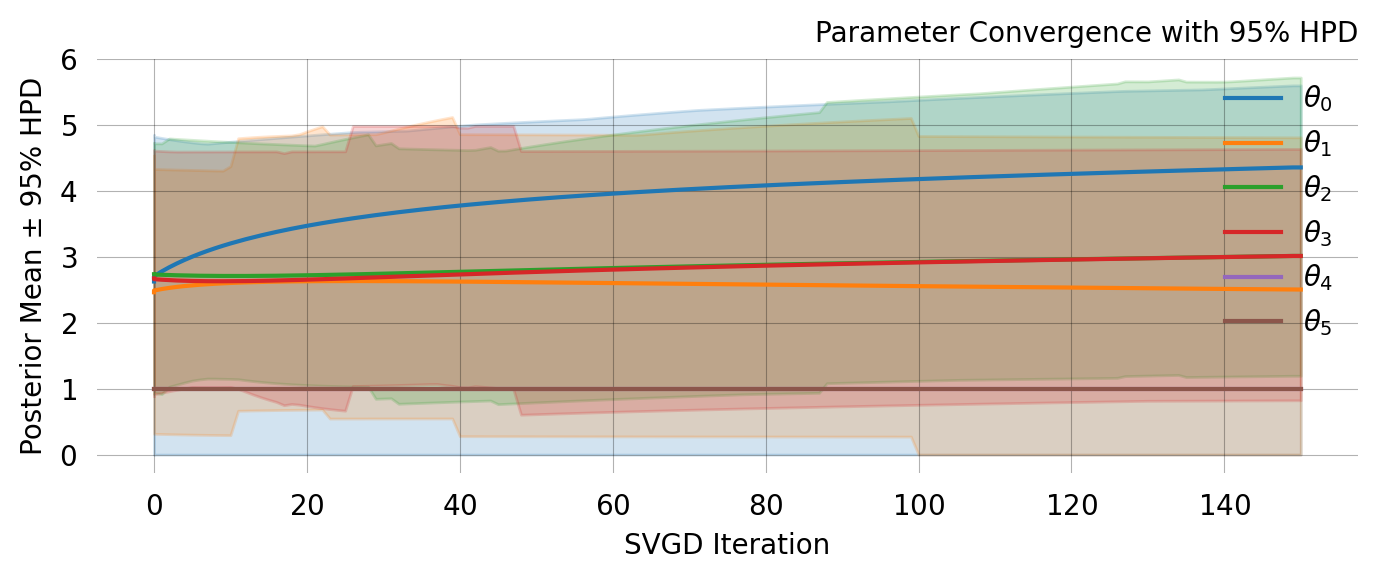

<Figure size 500x370 with 0 Axes>

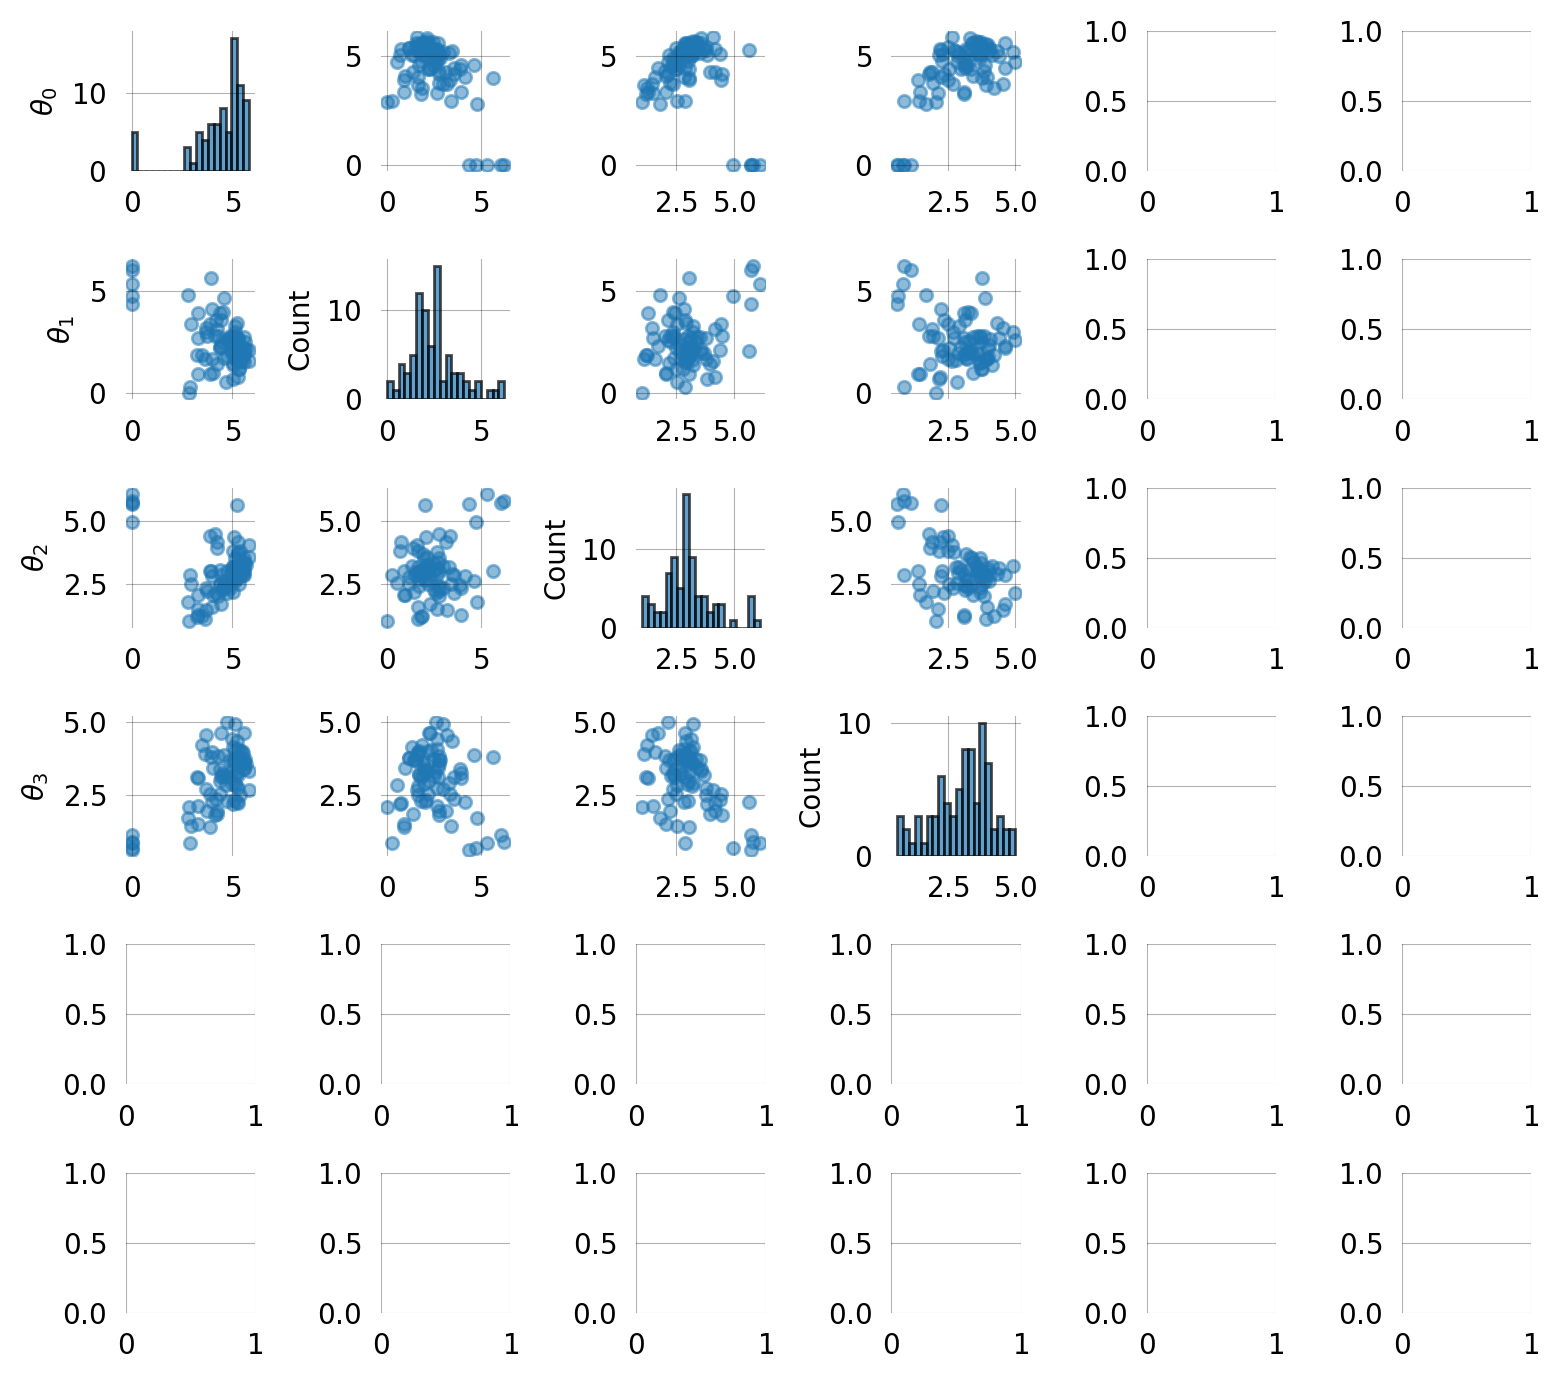

<Figure size 500x370 with 0 Axes>

In [18]:
pi_oliv = pi_df.loc["Southern olive", "pi"]
Ne_ref_oliv = pi_oliv / (4 * MUT_RATE)
res_im = svgd_im.get_results()
theta_im = res_im["theta_mean"]

N1_im = (1 / theta_im[0]) * Ne_ref_oliv
N2_im = (1 / theta_im[1]) * Ne_ref_oliv
Na_im = (1 / theta_im[3]) * Ne_ref_oliv
m_im  = theta_im[2] / (2 * Ne_ref_oliv)
t_split_years = epochs_im[1] * 2 * Ne_ref_oliv * GEN_TIME

print(f"\nIM-model biologisk fortolkning:")
print(f"  N_ref (fra pi):           {Ne_ref_oliv:,.0f}")
print(f"  N1 (Southern olive):      {N1_im:,.0f} individer")
print(f"  N2 (Eastern yellow):      {N2_im:,.0f} individer")
print(f"  N_ancestral:              {Na_im:,.0f} individer")
print(f"  Migration (m):            {m_im:.2e} per lineage per generation")
print(f"  Split-tid:                {t_split_years:,.0f} år")
print()
print(f"  Sammenlign: Sørensen et al. (2023) estimerer split ~1 mio. år siden")

svgd_im.plot_ci(ci_method="hpd")
plt.suptitle("Posterior CI — Southern olive (IM-model)")
plt.show()

svgd_im.plot_pairwise()
plt.suptitle("Posterior pairwise — IM-model", y=1.02)
plt.show()

## Samlet resultat

In [19]:
print("=" * 60)
print("SAMLET OVERBLIK — BAVIAN RESULTATER")
print("=" * 60)
print()
print("Populationskarakteristik:")
print(summary.round(4).to_string())
print()
print("\nTwo-island model (Eastern yellow):")
print(f"  N1:     {N1_est:,.0f}   N2:    {N2_est:,.0f}   m: {m_est:.2e} /gen")
print()
print("IM-model (Southern olive vs. Eastern yellow):")
print(f"  N1:     {N1_im:,.0f}   N2:    {N2_im:,.0f}")
print(f"  N_anc:  {Na_im:,.0f}   m:     {m_im:.2e} /gen")
print(f"  Split:  {t_split_years:,.0f} år  (Sørensen et al.: ~1 mio. år)")

SAMLET OVERBLIK — BAVIAN RESULTATER

Populationskarakteristik:
                             pi  Ne_ref  Tajima's D
Eastern yellow (Mikumi)  0.0026   71788      0.0009
Kinda                    0.0029   79458     -0.0206
Southern olive           0.0020   54704     -0.0335
Western yellow (Mahale)  0.0029   79663     -0.0327
Olive gog                0.0017   48388     -0.0235


Two-island model (Eastern yellow):
  N1:     13,871   N2:    25,215   m: 1.39e-05 /gen

IM-model (Southern olive vs. Eastern yellow):
  N1:     12,548   N2:    21,831
  N_anc:  18,141   m:     2.76e-05 /gen
  Split:  1,203,497 år  (Sørensen et al.: ~1 mio. år)


# Modelsammenligning på baviandata

Formålet med denne notebook er at sammenligne tre modeller på det *samme* datasæt (Eastern yellow baboon) og afgøre, hvilken der bedst beskriver populationens demografiske historie:

1. **Standard coalescent** — en population, konstant $N_e$
2. **To-island-model** — to populationer med løbende migration
3. **IM-model** — isolation with migration (split + post-split migration)

Jeg bruger log-likelihood og AIC til at sammenligne modellerne og laver posterior predictive checks på SFS.

Data indlæses fra filer genereret i notebook 03.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level,
)
set_log_level("WARNING")

import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from scipy import stats as scipy_stats

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")
%config InlineBackend.figure_format = "svg"

MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)
all_pairs = partial(combinations_with_replacement, r=2)
print("Imports OK")

Imports OK


## 1. Indlæs baviandata fra notebook 03

In [2]:
def load_baboon_ktons(path, n_samples_use, seed=0):
    p = Path(path)
    if not p.exists():
        print(f"[advarsel] {p} mangler — kør notebook 03 først.")
        return None
    df = pd.read_csv(p)
    df = df[df["nr_samples"] >= n_samples_use].copy()
    if len(df) == 0:
        return None
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=n_samples_use,
    )
    return k[(k > 0) & (k < n_samples_use)]

nr_samples = 4
k_east = load_baboon_ktons(OUT_DIR / "derived_counts_yellow_east.csv", nr_samples)
print(f"Eastern yellow: {len(k_east):,} segregerende SNPs (n={nr_samples})")

# Indlæs heterozygositet til Ne-kalibrering
pi_df = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)
pi_east = pi_df.loc["Eastern yellow (Mikumi)", "pi"]
Ne_ref  = pi_east / (4 * MUT_RATE)
print(f"π = {pi_east:.6f}  →  N_ref = {Ne_ref:,.0f}")

Eastern yellow: 346,922 segregerende SNPs (n=4)
π = 0.002584  →  N_ref = 71,789


## 2. Model A: Standard coalescent (én population)

Baselinjemodellen: alle $n$ lineages er i én population med konstant $N_e$.
Én parameter: $\theta_0 = 1/N_e$.

In [3]:
@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_1pop = Graph(coalescent_1param)

# Joint-probability graf til SFS-baseret inferens
mutation_rate = 1.0
indexer_1pop = StateIndexer(lineages=[Property("descendants", min_value=1, max_value=nr_samples)])

joint_1pop = graph_1pop.joint_prob_graph(
    indexer_1pop,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate,
)
tbl_1pop = joint_1pop.joint_prob_table()
feature_cols_1pop = [c for c in tbl_1pop.columns if c.startswith("descendants")]
allowed_1pop = set(tuple(int(x) for x in r) for r in tbl_1pop[feature_cols_1pop].values)

obs_1pop = []
for k in k_east:
    o = [0] * len(feature_cols_1pop)
    if 0 < k - 1 < len(o):
        o[k - 1] = 1
    if tuple(o) in allowed_1pop:
        obs_1pop.append(o)

rng = np.random.default_rng(42)
obs_1pop_use = [obs_1pop[i] for i in rng.choice(len(obs_1pop), min(5000, len(obs_1pop)), replace=False)]
print(f"Model A — brugbare observationer: {len(obs_1pop_use):,}")

Model A — brugbare observationer: 5,000


In [ ]:
mom_1pop = joint_1pop.method_of_moments(obs_1pop_use, fixed=[(1, mutation_rate)])

svgd_1pop = joint_1pop.svgd(
    obs_1pop_use,
    prior=mom_1pop.prior,
    fixed=[(1, mutation_rate)],
    learning_rate=ExpStepSize(first_step=0.06, last_step=0.01, tau=30.0),
    n_particles=80,
    n_iterations=120,
)
svgd_1pop.summary()

## 3. Model B: To-island-model (konstant migration)

To populationer, tre parametre: $1/N_1$, $1/N_2$, $m$.
Se notebook 04 for detaljeret gennemgang af modelbygningen.

In [5]:
indexer_2i = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ]
)
ipv_2i = [0] * indexer_2i.state_length
ipv_2i[indexer_2i.lineages.props_to_index(descendants=1, in_pop=1)] = nr_samples

@with_ipv(ipv_2i)
def two_island(state, indexer=None):
    transitions = []
    if state.sum() <= 1: return transitions
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if pi.in_pop != pj.in_pop: continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer.lineages.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = [rate if pi.in_pop==1 else 0, rate if pi.in_pop==2 else 0, 0]
        transitions.append([new, coeff])
    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.lineages.index_to_props(i)
        other = 2 if pi.in_pop == 1 else 1
        new = state.copy(); new[i] -= 1
        k = indexer.lineages.props_to_index(descendants=pi.descendants, in_pop=other)
        new[k] += 1
        transitions.append([new, [0, 0, state[i]]])
    return transitions

graph_2i = Graph(two_island, indexer=indexer_2i)
joint_2i = graph_2i.joint_prob_graph(
    indexer_2i, reward_only=["descendants"],
    reward_limit=1, tot_reward_limit=2, mutation_rate=mutation_rate,
)
tbl_2i = joint_2i.joint_prob_table()
feature_cols_2i = [c for c in tbl_2i.columns if c.startswith("descendants")]
allowed_2i = set(tuple(int(x) for x in r) for r in tbl_2i[feature_cols_2i].values)

obs_2i = []
for k in k_east:
    o = [0] * len(feature_cols_2i)
    if 0 < k - 1 < len(o): o[k - 1] = 1
    if tuple(o) in allowed_2i: obs_2i.append(o)

obs_2i_use = [obs_2i[i] for i in rng.choice(len(obs_2i), min(5000, len(obs_2i)), replace=False)]
print(f"Model B — brugbare observationer: {len(obs_2i_use):,}")

Model B — brugbare observationer: 5,000


In [ ]:
MUT_IDX_2i = joint_2i.param_length() - 1
fixed_2i = [(MUT_IDX_2i, mutation_rate)]
mom_2i = joint_2i.method_of_moments(obs_2i_use, fixed=fixed_2i)

svgd_2i = joint_2i.svgd(
    obs_2i_use,
    prior=mom_2i.prior,
    fixed=fixed_2i,
    learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=35.0),
    n_particles=80,
    n_iterations=150,
)
svgd_2i.summary()

## 4. Model C: IM-model (isolation with migration)

Fire parametre: $1/N_1$, $1/N_2$, $m$, $1/N_a$ + split-tid $t_s$ (sat fast til 1.0 coalescent-enhed).
Se notebook 05 for detaljeret gennemgang.

In [7]:
def add_epoch(graph, callback, epochs, epoch_idx, indexer):
    epoch = epochs[epoch_idx]
    stop_probs   = np.array(graph.stop_probability(epoch))
    accum_v_time = np.array(graph.accumulated_occupancy(epoch))
    with np.errstate(invalid="ignore"):
        etr = stop_probs / accum_v_time
    for i in range(1, graph.vertices_length() - 1):
        if etr is None or np.isnan(etr[i]): continue
        if graph.vertex_at(i).edges_length() == 0: continue
        v = graph.vertex_at(i); s = v.state()
        if not s[indexer.epoch] == epoch_idx - 1: continue
        ss = s.copy(); ss[indexer.epoch] = epoch_idx
        child = graph.find_or_create_vertex(ss)
        coeff = np.zeros(graph.param_length()); coeff[-1] = etr[i]
        v.add_edge(child, coeff)
    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)

indexer_im = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ],
    slots=["epoch"],
)
ipv_im = [0] * indexer_im.state_length
ipv_im[indexer_im.props_to_index(descendants=1, in_pop=1)] = nr_samples
N_PARAMS_IM = 5
t_split = 1.0
epochs_im = [0.0, t_split]

def im_callback(state, epochs=None, epoch_idx=None, indexer=None):
    transitions = []; epoch_idx = int(epoch_idx)
    if state[indexer.epoch] != epoch_idx: return transitions
    ls = sum(state[k] for k in range(indexer.state_length) if k != indexer.epoch)
    if ls <= 1: return transitions
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if epoch_idx == 0 and pi.in_pop != pj.in_pop: continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer_im.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = np.zeros(N_PARAMS_IM)
        if epoch_idx == 0: coeff[0 if pi.in_pop==1 else 1] = rate
        else: coeff[3] = rate
        transitions.append([new, coeff])
    if epoch_idx == 0:
        for i in range(indexer.state_length):
            if i == indexer.epoch or state[i] == 0: continue
            pi = indexer.lineages.index_to_props(i)
            other = 2 if pi.in_pop == 1 else 1
            new = state.copy(); new[i] -= 1
            k = indexer_im.props_to_index(descendants=pi.descendants, in_pop=other)
            new[k] += 1
            coeff = np.zeros(N_PARAMS_IM); coeff[2] = state[i]
            transitions.append([new, coeff])
    return transitions

theta_init = [1.0, 1.0, 0.5, 1.0, 1.0]
graph_im = Graph(im_callback, ipv=ipv_im, epochs=epochs_im, epoch_idx=0, indexer=indexer_im)
graph_im.update_weights(theta_init)
add_epoch(graph_im, im_callback, epochs_im, 1, indexer_im)
graph_im.update_weights(theta_init)
print(f"IM-graf: {graph_im.vertices_length()} states, {graph_im.param_length()} parametre")

IM-graf: 41 states, 5 parametre


In [8]:
joint_im = graph_im.joint_prob_graph(
    indexer_im, reward_only=["descendants"],
    reward_limit=1, tot_reward_limit=2, mutation_rate=mutation_rate,
)
tbl_im = joint_im.joint_prob_table()
feature_cols_im = [c for c in tbl_im.columns if c.startswith("descendants")]
allowed_im = set(tuple(int(x) for x in r) for r in tbl_im[feature_cols_im].values)

obs_im = []
for k in k_east:
    o = [0] * len(feature_cols_im)
    if 0 < k - 1 < len(o): o[k - 1] = 1
    if tuple(o) in allowed_im: obs_im.append(o)

obs_im_use = [obs_im[i] for i in rng.choice(len(obs_im), min(5000, len(obs_im)), replace=False)]
print(f"Model C — brugbare observationer: {len(obs_im_use):,}")

MUT_IDX_IM   = joint_im.param_length() - 1
EPOCH_IDX_IM = MUT_IDX_IM - 1
fixed_im = [(EPOCH_IDX_IM, 1.0), (MUT_IDX_IM, mutation_rate)]

prior_im = [GaussPrior(ci=[0.1, 5.0]), GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.0, 3.0]), GaussPrior(ci=[0.1, 5.0]),
            None, None][:joint_im.param_length()]

svgd_im = joint_im.svgd(
    obs_im_use,
    prior=prior_im,
    fixed=fixed_im,
    learning_rate=ExpStepSize(first_step=0.06, last_step=0.01, tau=40.0),
    n_particles=80,
    n_iterations=120,
)
svgd_im.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         4.5471     3.3691     1.1547     0.9335       4.7171      
1          No         0.8231     2.3558     1.3299     0.0000       4.4890      
2          No         2.9226     2.3738     0.8937     0.1203       3.4542      
3          No         3.9841     3.1771     0.9464     1.1524       4.6755      
4          Yes        1.0000     NA         NA         NA           NA          
5          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 120


## 5. Modelsammenligning: AIC og log-likelihood

Jeg beregner log-likelihood for hver model under posterior mean-parametrene og sammenligner med AIC.
$\text{AIC} = 2k - 2\ell$, hvor $k$ er antal frie parametre.

In [ ]:
def log_likelihood_joint(joint_graph, observations, theta_values, fixed_list):
    """Beregner log-likelihood under theta_values for joint probability model."""
    joint_graph.update_weights(theta_values)
    tbl = joint_graph.joint_prob_table()
    feat_cols = [c for c in tbl.columns if c.startswith("descendants")]
    prob_map = {tuple(int(x) for x in row[feat_cols]): row["prob"]
                for _, row in tbl.iterrows()}
    ll = 0.0
    for obs in observations:
        p = prob_map.get(tuple(obs), 1e-300)
        ll += np.log(max(p, 1e-300))
    return ll


# Fælles testobservationer (brug obs_1pop_use som reference)
test_obs = obs_1pop_use[:2000]

r1 = svgd_1pop.get_results(); t1 = r1["theta_mean"]
r2 = svgd_2i.get_results();   t2 = r2["theta_mean"]
r3 = svgd_im.get_results();   t3 = r3["theta_mean"]

# Opdater med full theta (inkl. fikserede) til likelihood-beregning
t1_full = list(t1) + [mutation_rate]
t2_full = list(t2); t2_full[MUT_IDX_2i] = mutation_rate
t3_full = list(t3); t3_full[EPOCH_IDX_IM] = 1.0; t3_full[MUT_IDX_IM] = mutation_rate

# Konverter observations til samme format
def to_obs(k_arr, tbl, feat_cols):
    allowed = set(tuple(int(x) for x in r) for r in tbl[feat_cols].values)
    result = []
    for k in k_arr[:2000]:
        o = [0] * len(feat_cols)
        if 0 < k-1 < len(o): o[k-1] = 1
        if tuple(o) in allowed: result.append(o)
    return result[:2000]

obs_cmp_1 = to_obs(k_east, tbl_1pop, feature_cols_1pop)
obs_cmp_2 = to_obs(k_east, tbl_2i,   feature_cols_2i)
obs_cmp_3 = to_obs(k_east, tbl_im,   feature_cols_im)
n_cmp = min(len(obs_cmp_1), len(obs_cmp_2), len(obs_cmp_3), 1000)

ll_A = log_likelihood_joint(joint_1pop, obs_cmp_1[:n_cmp], t1_full, [(1, mutation_rate)])
ll_B = log_likelihood_joint(joint_2i,   obs_cmp_2[:n_cmp], t2_full, [(MUT_IDX_2i, mutation_rate)])
ll_C = log_likelihood_joint(joint_im,   obs_cmp_3[:n_cmp], t3_full, fixed_im)

k_A, k_B, k_C = 1, 3, 4
aic_A = 2*k_A - 2*ll_A
aic_B = 2*k_B - 2*ll_B
aic_C = 2*k_C - 2*ll_C

delta_B = aic_B - aic_A
delta_C = aic_C - aic_A

cmp_df = pd.DataFrame({
    "Model":      ["A: Standard coalescent", "B: To-ø-model", "C: IM-model"],
    "Parametre":  [k_A, k_B, k_C],
    "LogLik":     [round(ll_A,1), round(ll_B,1), round(ll_C,1)],
    "AIC":        [round(aic_A,1), round(aic_B,1), round(aic_C,1)],
    "ΔAIC vs A":  [0.0, round(delta_B,1), round(delta_C,1)],
    "Bedst":      [aic_A == min(aic_A,aic_B,aic_C),
                   aic_B == min(aic_A,aic_B,aic_C),
                   aic_C == min(aic_A,aic_B,aic_C)],
})
print(cmp_df.to_string(index=False))
print()
print("ΔAIC < -2: modellen er bedre. ΔAIC > 2: modellen er dårligere.")
cmp_df.to_csv(OUT_DIR / "model_comparison_aic.csv", index=False)

## 6. Posterior-sammenligning: N_e og migration

Jeg konverterer alle tre modellers posterior mean-estimater til biologiske enheder (individer, per generation) for sammenligning.

In [ ]:
def coal_to_bio(theta_val, Ne_ref):
    """Konverter coalescent-rate θ = 1/N_rel til N_e i individer."""
    return (1 / theta_val) * Ne_ref

res_A = svgd_1pop.get_results()["theta_mean"]
res_B = svgd_2i.get_results()["theta_mean"]
res_C = svgd_im.get_results()["theta_mean"]

rows = []
rows.append({"Model":"A: Standard","Parameter":"N_e","Coalescent":f"{res_A[0]:.3f}","Biologisk":f"{coal_to_bio(res_A[0],Ne_ref):,.0f} ind."})
rows.append({"Model":"B: To-ø","Parameter":"N_1 (Eastern yellow)","Coalescent":f"{res_B[0]:.3f}","Biologisk":f"{coal_to_bio(res_B[0],Ne_ref):,.0f} ind."})
rows.append({"Model":"B: To-ø","Parameter":"N_2","Coalescent":f"{res_B[1]:.3f}","Biologisk":f"{coal_to_bio(res_B[1],Ne_ref):,.0f} ind."})
rows.append({"Model":"B: To-ø","Parameter":"migration m","Coalescent":f"{res_B[2]:.3f}","Biologisk":f"{res_B[2]/(2*Ne_ref):.2e} /gen"})
rows.append({"Model":"C: IM","Parameter":"N_1 (Eastern yellow)","Coalescent":f"{res_C[0]:.3f}","Biologisk":f"{coal_to_bio(res_C[0],Ne_ref):,.0f} ind."})
rows.append({"Model":"C: IM","Parameter":"N_2","Coalescent":f"{res_C[1]:.3f}","Biologisk":f"{coal_to_bio(res_C[1],Ne_ref):,.0f} ind."})
rows.append({"Model":"C: IM","Parameter":"migration m","Coalescent":f"{res_C[2]:.3f}","Biologisk":f"{res_C[2]/(2*Ne_ref):.2e} /gen"})
rows.append({"Model":"C: IM","Parameter":"N_ancestral","Coalescent":f"{res_C[3]:.3f}","Biologisk":f"{coal_to_bio(res_C[3],Ne_ref):,.0f} ind."})
rows.append({"Model":"C: IM","Parameter":"Split-tid","Coalescent":f"{t_split:.2f} coal.","Biologisk":f"{t_split*2*Ne_ref*GEN_TIME:,.0f} år"})

bio_df = pd.DataFrame(rows)
print(bio_df.to_string(index=False))
bio_df.to_csv(OUT_DIR / "biological_parameters.csv", index=False)

## 7. Konvergenscheck

Vigtig validering: er SVGD-partiklerne konvergeret for alle tre modeller?

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, svgd_obj, title in zip(axes,
                                [svgd_1pop, svgd_2i, svgd_im],
                                ["A: Standard coalescent", "B: To-ø", "C: IM"]):
    svgd_obj.plot_convergence(ax=ax)
    ax.set_title(title)
plt.suptitle("Konvergenscheck — alle tre modeller", y=1.02)
plt.tight_layout()
plt.show()

## 8. Konklusion

I næste notebook (08) udvider jeg analysen til alle populationspar for at kortlægge migrationsnetværket mellem bavian-populationerne.
